#### How to Perform Data Cleaning for Machine Learning with Python . 

https://machinelearningmastery.com/basic-data-cleaning-for-machine-learning/

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("oil-spill.csv")
df.shape
numpydf = df.to_numpy()
for i in range(df.shape[1]):
    #print(df.columns[i], np.unique(df.iloc[:, i].to_numpy()))
    print(i, len(np.unique(numpydf[:, i])))

0 238
1 296
2 926
3 932
4 179
5 374
6 819
7 617
8 560
9 57
10 576
11 59
12 73
13 107
14 53
15 91
16 892
17 809
18 169
19 53
20 68
21 9
22 1
23 92
24 9
25 8
26 9
27 308
28 447
29 391
30 107
31 42
32 4
33 45
34 141
35 110
36 3
37 757
38 9
39 9
40 387
41 219
42 643
43 648
44 499
45 2
46 936
47 169
48 286
49 2


nunique doesn't give index and count by default as mentioned in the article

In [3]:
for i,count in enumerate(df.nunique()):
        print(i,  count)

0 238
1 296
2 926
3 932
4 179
5 374
6 819
7 617
8 560
9 57
10 576
11 59
12 73
13 107
14 53
15 91
16 892
17 809
18 169
19 53
20 68
21 9
22 1
23 92
24 9
25 8
26 9
27 308
28 447
29 391
30 107
31 42
32 4
33 45
34 141
35 110
36 3
37 757
38 9
39 9
40 387
41 219
42 643
43 648
44 499
45 2
46 936
47 169
48 286
49 2


### Delete column having only 1 value

In [4]:
col_to_del=[i for i, count in enumerate(df.nunique()) if count==1]
print (df.columns[col_to_del])
#axis=1 means columns , 0 - rows.
#we must use df.columns since drop accepts column labels, not indices. So we need to convert the indices to labels using df.columns[col_to_del]
#cleaned_df= df.drop(df.columns[col_to_del], axis=1)
#Use columns= syntax to specify the columns to drop, 
cleaned_df= df.drop(columns=df.columns[col_to_del])
print(cleaned_df.shape)

Index(['0'], dtype='str')
(936, 49)


Let's try dropping from numpy array

In [5]:
ncol_to_del = [i for i in range(numpydf.shape[1]) if len(np.unique(numpydf[:, i]))==1]
print(ncol_to_del)
print(numpydf.shape)
cleaned_numpydf = np.delete(numpydf, ncol_to_del, axis=1)
print(cleaned_numpydf.shape)


[22]
(936, 50)
(936, 49)


### Handling columns containing few unique values 2,4 or 9

In [6]:
for i in range(numpydf.shape[1]):
	num = len(pd.unique(numpydf[:, i]))
	percentage = float(num) / numpydf.shape[0] * 100
	if(percentage < 1):
	 print('%d, %d, %.1f%%' % (i, num, percentage))

21, 9, 1.0%
22, 1, 0.1%
24, 9, 1.0%
25, 8, 0.9%
26, 9, 1.0%
32, 4, 0.4%
36, 3, 0.3%
38, 9, 1.0%
39, 9, 1.0%
45, 2, 0.2%
49, 2, 0.2%


### Remove Columns That Have A Low Variance

In [7]:
from sklearn.feature_selection import VarianceThreshold
dfvalues = df.values
X = dfvalues[:,:-1]
y = dfvalues[:,-1]

print(X.shape,y.shape)
threshold = VarianceThreshold()
X_sel = threshold.fit_transform(X)
print(X_sel.shape)

(936, 49) (936,)
(936, 48)


VarianceThreshold=0.00, Features=48
VarianceThreshold=0.05, Features=37
VarianceThreshold=0.10, Features=36
VarianceThreshold=0.15, Features=35
VarianceThreshold=0.20, Features=35
VarianceThreshold=0.25, Features=35
VarianceThreshold=0.30, Features=35
VarianceThreshold=0.35, Features=35
VarianceThreshold=0.40, Features=35
VarianceThreshold=0.45, Features=33
VarianceThreshold=0.50, Features=31


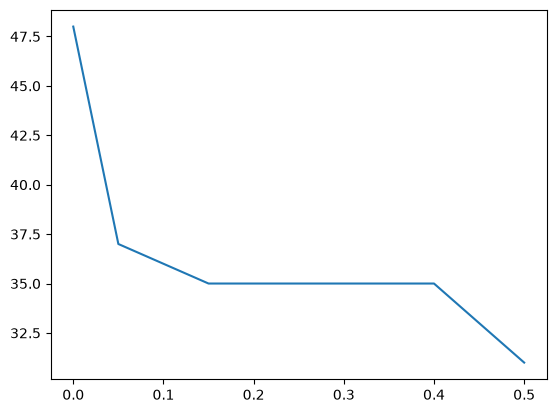

In [8]:
from matplotlib import pyplot as plt
thresholds = np.arange(0.0, 0.55, 0.05)
results=list()
for t in thresholds:
    selection = VarianceThreshold(threshold=t)
    X_sel = selection.fit_transform(X)
    results.append(X_sel.shape[1])
    print('VarianceThreshold=%.2f, Features=%d' % (t, X_sel.shape[1]))

plt.plot(thresholds, results)
plt.show()

### Removing duplicate rows

In [9]:
irisdf = pd.read_csv("iris.csv")
dups = irisdf.duplicated()
 

print(irisdf.shape)
print(dups.any())
print(irisdf[dups])
dedupsdf = irisdf.drop_duplicates()
print(dedupsdf.shape)

(149, 5)
True
     5.1  3.5  1.4  0.2     Iris-setosa
33   4.9  3.1  1.5  0.1     Iris-setosa
36   4.9  3.1  1.5  0.1     Iris-setosa
141  5.8  2.7  5.1  1.9  Iris-virginica
(146, 5)


## How To Prepare Your Data For Machine Learning in Python with Scikit-Learn
https://machinelearningmastery.com/prepare-data-machine-learning-python-scikit-learn/

** Rescale Data : MinMaxScaler **

In [10]:
from sklearn.preprocessing import MinMaxScaler

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

dfs = pd.read_csv("pima-indians-diabetes.csv", names=names)
dfs.shape
dfs_values = dfs.values
print(dfs.head())
len(dfs.columns)
X = dfs_values[:,:-1]
y = dfs_values[:,-1]
print(X.shape,y.shape)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
np.set_printoptions(precision=3)
print(X_scaled[0:5,:])

   preg  plas  pres  skin  test  mass   pedi  age  class
0     6   148    72    35     0  33.6  0.627   50      1
1     1    85    66    29     0  26.6  0.351   31      0
2     8   183    64     0     0  23.3  0.672   32      1
3     1    89    66    23    94  28.1  0.167   21      0
4     0   137    40    35   168  43.1  2.288   33      1
(768, 8) (768,)
[[0.353 0.744 0.59  0.354 0.    0.501 0.234 0.483]
 [0.059 0.427 0.541 0.293 0.    0.396 0.117 0.167]
 [0.471 0.92  0.525 0.    0.    0.347 0.254 0.183]
 [0.059 0.447 0.541 0.232 0.111 0.419 0.038 0.   ]
 [0.    0.688 0.328 0.354 0.199 0.642 0.944 0.2  ]]


### Standardize - Gaussian distribution 

columns = V + Mean / SD

   preg  plas  pres  skin  test  mass   pedi  age  class
0     6   148    72    35     0  33.6  0.627   50      1
1     1    85    66    29     0  26.6  0.351   31      0
2     8   183    64     0     0  23.3  0.672   32      1
3     1    89    66    23    94  28.1  0.167   21      0
4     0   137    40    35   168  43.1  2.288   33      1
[[ 0.64   0.848  0.15   0.907 -0.693  0.204  0.468  1.426]
 [-0.845 -1.123 -0.161  0.531 -0.693 -0.684 -0.365 -0.191]
 [ 1.234  1.944 -0.264 -1.288 -0.693 -1.103  0.604 -0.106]
 [-0.845 -0.998 -0.161  0.155  0.123 -0.494 -0.921 -1.042]
 [-1.142  0.504 -1.505  0.907  0.766  1.41   5.485 -0.02 ]]
<class 'numpy.ndarray'>


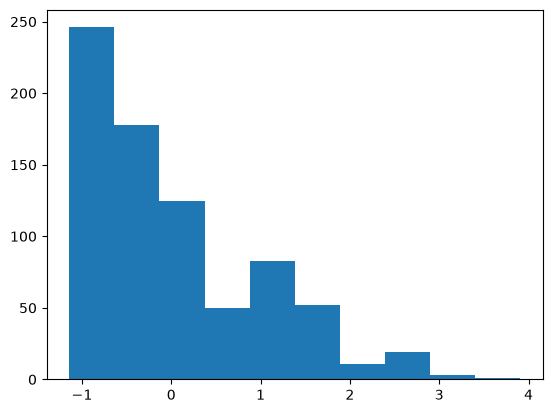

array([[<Axes: title={'center': 'preg'}>,
        <Axes: title={'center': 'plas'}>,
        <Axes: title={'center': 'pres'}>],
       [<Axes: title={'center': 'skin'}>,
        <Axes: title={'center': 'test'}>,
        <Axes: title={'center': 'mass'}>],
       [<Axes: title={'center': 'pedi'}>,
        <Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

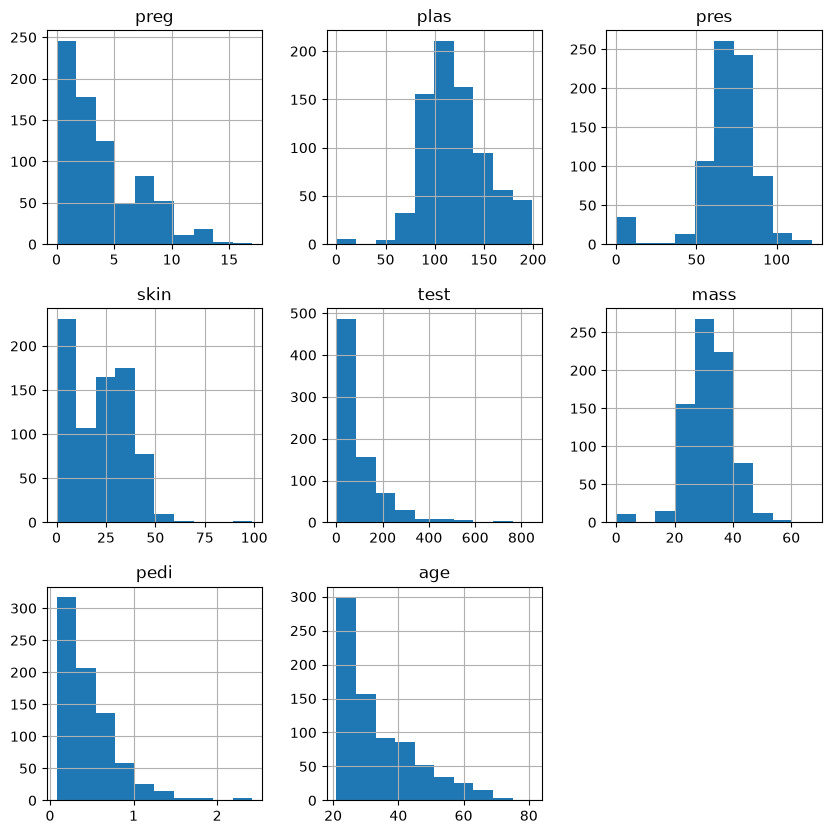

In [11]:
from sklearn.preprocessing import StandardScaler
%matplotlib inline
import matplotlib.pyplot as plt

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

dfs = pd.read_csv("pima-indians-diabetes.csv", names=names)
dfs.shape
dfs_values = dfs.values
print(dfs.head())

X = dfs_values[:,:-1]
y = dfs_values[:,-1]

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
np.set_printoptions(precision=3)
print(X_scaled[:5,:])

print(type(X_scaled))

plt.hist(X_scaled[:,0])
plt.show()

dfs.hist(column=names[:-1], bins=10, figsize=(10,10))

Normalization : rows == 1
Euclidean length of each row should be 1
EL = sqrt(data^2) -> data = [3,4,6,8] ->
data/EL

In [12]:
from sklearn.preprocessing import Normalizer


names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

dfs = pd.read_csv("pima-indians-diabetes.csv", names=names)
dfs.shape
dfs_values = dfs.values
print(dfs.head())

X = dfs_values[:,:-1]
y = dfs_values[:,-1]
normalizer = Normalizer().fit(X)
X_normalized = normalizer.transform(X)

np.set_printoptions(precision=3)
print(np.sqrt(np.sum(X_normalized**2, axis=1)))


   preg  plas  pres  skin  test  mass   pedi  age  class
0     6   148    72    35     0  33.6  0.627   50      1
1     1    85    66    29     0  26.6  0.351   31      0
2     8   183    64     0     0  23.3  0.672   32      1
3     1    89    66    23    94  28.1  0.167   21      0
4     0   137    40    35   168  43.1  2.288   33      1
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 

### Binarize Data (Make Binary) 

helpful - example. age > 50

In [13]:
from sklearn.preprocessing import Binarizer


names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

dfs = pd.read_csv("pima-indians-diabetes.csv", names=names)
dfs.shape
dfs_values = dfs.values
print(dfs.head())

X = dfs_values[:,:-1]
y = dfs_values[:,-1]
binarizer = Binarizer(threshold=0.9).fit(X)
binaryX = binarizer.transform(X)
# summarize transformed data
np.set_printoptions(precision=3)
print(binaryX[0:5,:])

   preg  plas  pres  skin  test  mass   pedi  age  class
0     6   148    72    35     0  33.6  0.627   50      1
1     1    85    66    29     0  26.6  0.351   31      0
2     8   183    64     0     0  23.3  0.672   32      1
3     1    89    66    23    94  28.1  0.167   21      0
4     0   137    40    35   168  43.1  2.288   33      1
[[1. 1. 1. 1. 0. 1. 0. 1.]
 [1. 1. 1. 1. 0. 1. 0. 1.]
 [1. 1. 1. 0. 0. 1. 0. 1.]
 [1. 1. 1. 1. 1. 1. 0. 1.]
 [0. 1. 1. 1. 1. 1. 1. 1.]]


#### How to Remove Outliers for Machine Learning

https://machinelearningmastery.com/how-to-use-statistics-to-identify-outliers-in-data/

Generate random numbers with Gaussian distribution. By virtue of the distribution itself, there shall be 
few values that will be long way from the mean.

Generating random using NumPY.  

refer https://machinelearningmastery.com/how-to-generate-random-numbers-in-python/ for more info

### Standard Deviation Method 

In [14]:

np.random.seed(1)
data = 5 * np.random.randn(10000) + 50
# summarize
print(data[:5,])
print('mean=%.3f stdv=%.3f' % (np.mean(data), np.std(data)))

[58.122 46.941 47.359 44.635 54.327]
mean=50.049 stdv=4.994


Use SD * 3 (standard). 

Range is **mean - SD * 3 and mean + SD * 3**

values outside the range are outliers

In [15]:

#calculate summary statistics
data_mean, data_std = np.mean(data), np.std(data)
print('mean=%.3f stdv=%.3f' % (data_mean, data_std))
# identify outliers
cut_off = data_std * 3
lower, upper = data_mean - cut_off, data_mean + cut_off
print(lower, upper)

outliers = [x for x in data if x < lower or x > upper]
print(outliers[:5])
print('Identified outliers: %d' % len(outliers))
outliers_removed = [x for x in data if x >= lower and x <= upper]
print('Non-outlier observations: %d' % len(outliers_removed))

mean=50.049 stdv=4.994
35.06707562817479 65.03065093881625
[np.float64(65.15428556186015), np.float64(69.79301352018982), np.float64(66.60539378085183), np.float64(34.73117809786848), np.float64(34.23321274904475)]
Identified outliers: 29
Non-outlier observations: 9971


### Interquartile Range Method (IQR)₹

#### Box-and-Whisker Plot Summary

- **Box** → represents the middle 50% of the data
  - Starts at **Q1 (25th percentile)**
  - Ends at **Q3 (75th percentile)**
  - Size of the box = **IQR**
  
  $$IQR = Q3 - Q1$$

- **Line inside the box** → **Median (Q2)**

- **Whiskers** → extend from the box toward the most extreme **non-outlier** values

  Lower limit:
  $$Q1 - 1.5 \times IQR$$

  Upper limit:
  $$Q3 + 1.5 \times IQR$$

- **Points beyond the whiskers** → potential **outliers**

#### Visual

```text
        Whisker          Box                 Whisker
───────────────┬────────┌──────────┬───────────────┬────
               │        │          │               │
              Q1      Median       Q3              │
                       (Q2)                        │
                                                  Outlier

In [16]:
np.random.seed(1)
data = 5 * np.random.randn(10000) + 50
print(data[:5,])
q25,q75 = np.percentile(data, 25), np.percentile(data, 75)
print('25th percentile=%.3f, 75th percentile=%.3f' % (q25, q75))
iqr = q75 - q25
print('Interquartile range (IQR)=%.3f' % (iqr))
cut_off = iqr * 1.5
print('Cut-off for outliers: %.3f' % (cut_off))
lower, upper = q25 - cut_off, q75 + cut_off
print('Outlier lower bound: %.3f' % (lower))
print('Outlier upper bound: %.3f' % (upper))
outliers = [x for x in data if x < lower or x > upper]
print(outliers[:5])
print('Identified outliers: %d' % len(outliers))
outliers_removed = [x for x in data if x >= lower and x <= upper]
print('Non-outlier observations: %d' % len(outliers_removed))


[58.122 46.941 47.359 44.635 54.327]
25th percentile=46.685, 75th percentile=53.359
Interquartile range (IQR)=6.674
Cut-off for outliers: 10.011
Outlier lower bound: 36.675
Outlier upper bound: 63.370
[np.float64(36.0345749992673), np.float64(65.15428556186015), np.float64(36.08732766173539), np.float64(69.79301352018982), np.float64(36.045017966530764)]
Identified outliers: 81
Non-outlier observations: 9919


### Automatic Outlier Detection

```text
Feature 2
   ↑
   |
   |       • • •
   |      • • • •
   |       • • •
   |
   |                         X  ← possible outlier
   |
   +------------------------------→ Feature 1


  
                 Outlier Detection
                     │
                     ▼
            One-Class Classification
                     │
          Train using normal data
                     │
                     ▼
             Detect unusual data
                     │
          ┌──────────┴──────────┐
          ▼                     ▼
   Distance-based            LOF
   detection                 │
                             ▼
                    Compare local
                    neighborhoods
    
LOF gives each data point an outlier score.
Conceptually:
Point     LOF score
-------------------
A            1.0
B            1.1
C            0.9
D            1.2
E            4.8   ← likely outlier

In [29]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor


data = pd.read_csv("housing.csv")
dfv = data.values
X,y = dfv[:,:-1], dfv[:,-1]
print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# fit the model
model = LinearRegression()
model.fit(X_train, y_train)
# evaluate the model
yhat = model.predict(X_test)
# evaluate predictions
mae = mean_absolute_error(y_test, yhat)
print('MAE: %.3f' % mae)

# identify outliers in the training dataset
lof = LocalOutlierFactor()
yhat = lof.fit_predict(X_train)
# select all rows that are not outliers
mask = yhat != -1
X_train, y_train = X_train[mask, :], y_train[mask]
# summarize the shape of the updated training dataset
print(X_train.shape, y_train.shape)
# fit the model
model = LinearRegression()
model.fit(X_train, y_train)
# evaluate the model
yhat = model.predict(X_test)
# evaluate predictions
mae = mean_absolute_error(y_test, yhat)
print('MAE: %.3f' % mae)



(505, 13) (505,)
(338, 13) (167, 13) (338,) (167,)
MAE: 3.656
(291, 13) (291,)
MAE: 3.590
